Our data is in assignments\Assignment4\transformer_data.csv

It is "time","Y","Ta","S","I" 

It means 

• Yt: The transformer station temperature (◦C).

• Ta,t: The outdoor air temperature (◦C).

• Φs,t: The horizontal global solar radiation (W/m2) --> variable S in dataset

• ΦI,t: The load on the transformer station (kA). --> variable I in dataset


In this exercise, we shall develop models to predict the temperature evolution in transformer station
in a DSO (distribution system operator, distributing electricity from high-voltage grid out to the end
consumer) grid. Transformer stations are vital to the electricity transportation system, and having
the operate optimally is advantagous.
A brief introduction to a transformer station. Roughly speaking, a transformer station receives electricity at a high voltage and sends out electricity at a lower voltage. In this process, some energy is
lost in the transformer and converted into heat. DSO transformer stations typically use oil for cooling
(like water cooling, just with oil). The highest temperature inside the transformer station needs to be
below a given threshold in order to limit the speed of degradation of the transformer station and to
avoid it catching fire. In this data, a good approximation to this temperature is measured. We would
now like a model that is able to predict this temperature.


This is useful because we will be able to predict dangerous temperatures before they happen, and
because we will be able to relate the input (electricity load) to the output (temperature).

We want to relate the impact of I on Y


We have 7 days of hourly data, so 7*24 = 168 data points 

# 2.3

Start 00 | success=True | neg loglik=452.966 | message=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Start 01 | success=True | neg loglik=132.352 | message=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Start 02 | success=True | neg loglik=147.729 | message=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Start 03 | success=True | neg loglik=132.352 | message=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Start 04 | success=True | neg loglik=151.065 | message=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Start 05 | success=True | neg loglik=151.789 | message=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Start 06 | success=True | neg loglik=150.598 | message=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Start 07 | success=True | neg loglik=132.352 | message=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Start 08 | success=True | neg loglik=151.924 | message=CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Start 09 | success=True | ne

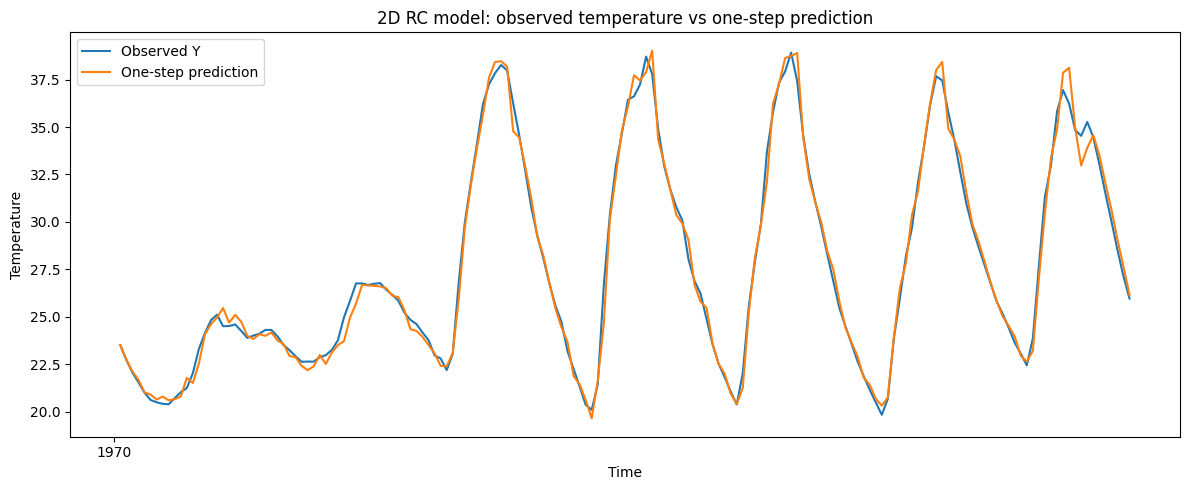

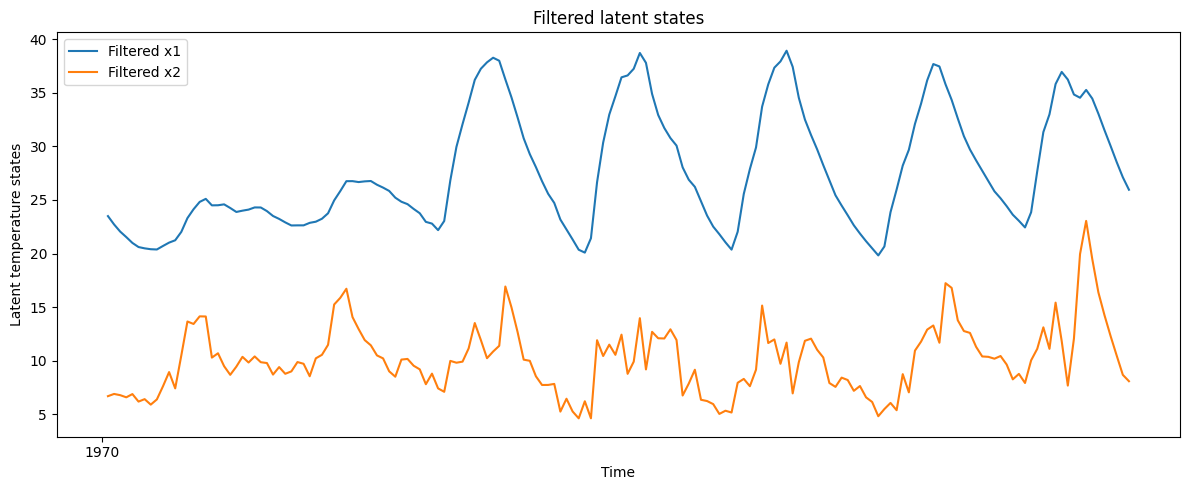

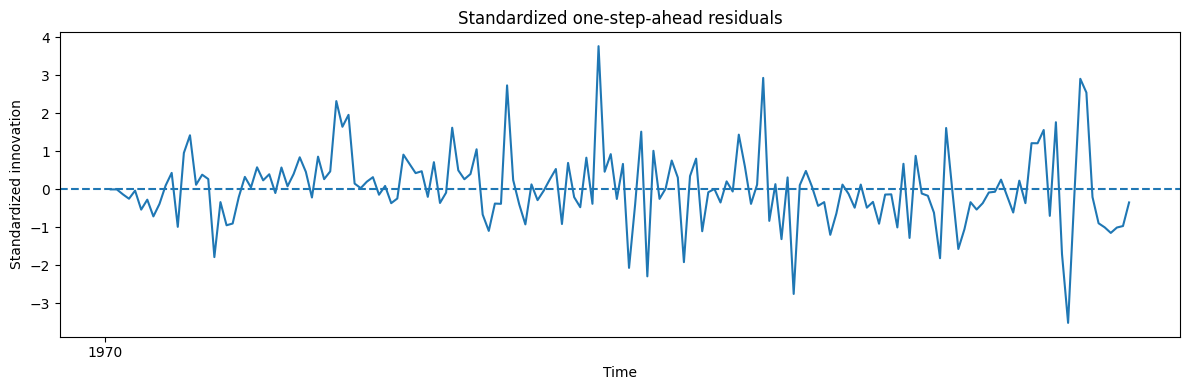

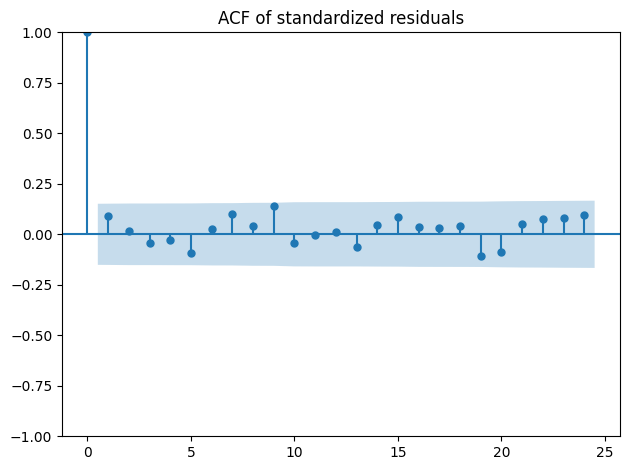

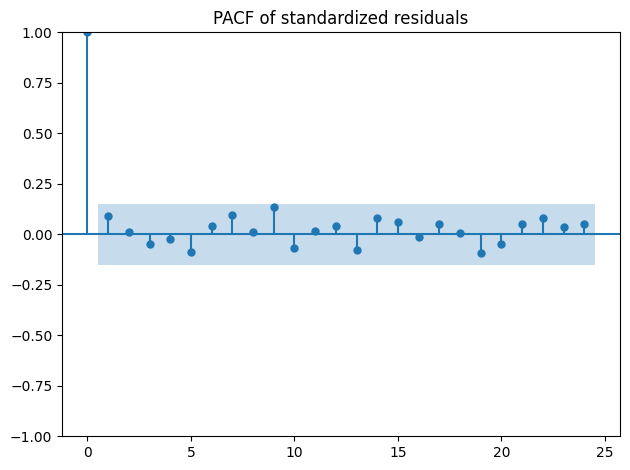

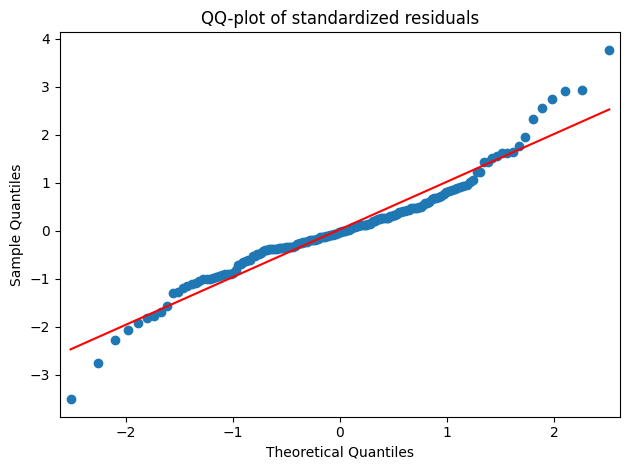


Matrix dimensions
-----------------
A shape: (2, 2)
B shape: (2, 3)
C shape: (1, 2)
Q shape: (2, 2)
R shape: (1, 1)

Estimated discrete-time A matrix
[[7.94081684e-01 1.40595265e-01]
 [6.09772815e-06 4.56462379e-01]]

Estimated discrete-time B matrix
[[6.53230511e-02 8.32946781e-07 1.05112178e-02]
 [5.43531523e-01 6.93067493e-06 4.25180710e-08]]


In [1]:
# ============================================================
# 2D RC STATE-SPACE MODEL WITH KALMAN FILTER + MLE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import expm
from scipy.optimize import minimize

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot


# ============================================================
# 1. LOAD DATA
# ============================================================

fp = r"C:\Users\leahi\Documents\DTU\Time Series Analysis\assignments\Assignment4\transformer_data.csv"

df = pd.read_csv(fp)

# Make sure the data are in time order
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

# Observation
y = df["Y"].to_numpy(dtype=float)

# Inputs
Ta = df["Ta"].to_numpy(dtype=float)

# Design choice:
# S is given in W/m^2. Dividing by 1000 gives kW/m^2.
# This keeps the optimizer from dealing with very small solar coefficients.
S = df["S"].to_numpy(dtype=float) / 1000.0

# Design choice:
# Transformer heat losses are physically closer to I^2 than I.
# If your professor explicitly wants raw I, set USE_I_SQUARED = False.
USE_I_SQUARED = True

I_raw = df["I"].to_numpy(dtype=float)
I_input = I_raw**2 if USE_I_SQUARED else I_raw

# Input matrix U_t has three inputs:
# u_t = [Ta_t, S_t, I_t^2]
U = np.column_stack([Ta, S, I_input])

dt = 1.0  # hourly data, so sampling interval is 1 hour


# ============================================================
# 2. PARAMETER NAMES
# ============================================================

PARAM_NAMES = [
    "k12",       # heat exchange rate from x2 to x1
    "k21",       # heat exchange rate from x1 to x2
    "k2a",       # heat exchange rate from ambient air to x2
    "kS",        # solar gain on x2
    "kI",        # load/current heating gain on x1
    "sigma_x1",  # process noise std for state x1
    "sigma_x2",  # process noise std for state x2
    "sigma_y",   # observation noise std
    "x1_0",      # initial value of state x1
    "x2_0",      # initial value of state x2
]


def unpack_theta(theta):
    """
    Convert parameter vector into a named dictionary.
    This avoids mistakes like using undefined variables such as par_names2.
    """
    return dict(zip(PARAM_NAMES, theta))


# ============================================================
# 3. CONTINUOUS-TIME RC MODEL
# ============================================================

def continuous_matrices(theta):
    """
    Build the continuous-time state-space matrices:

        dX/dt = A_c X + B_c u

    with

        X = [x1, x2]^T
        u = [Ta, S, I^2]^T

    Model:

        dx1/dt = k12 (x2 - x1) + kI I^2

        dx2/dt = k21 (x1 - x2)
                 + k2a (Ta - x2)
                 + kS S

    Therefore:

        A_c =
        [[-k12,       k12],
         [ k21, -(k21+k2a)]]

        B_c =
        [[ 0,   0,  kI],
         [k2a, kS,  0]]

    Dimensions:
        A_c is 2 x 2
        B_c is 2 x 3
    """

    p = unpack_theta(theta)

    k12 = p["k12"]
    k21 = p["k21"]
    k2a = p["k2a"]
    kS = p["kS"]
    kI = p["kI"]

    A_c = np.array([
        [-k12,          k12],
        [ k21, -(k21 + k2a)]
    ], dtype=float)

    B_c = np.array([
        [0.0, 0.0, kI],
        [k2a,  kS, 0.0]
    ], dtype=float)

    return A_c, B_c


# ============================================================
# 4. DISCRETIZATION USING BLOCK MATRIX EXPONENTIAL
# ============================================================

def discretize_state_space(A_c, B_c, dt=1.0):
    """
    Convert continuous-time system

        dX/dt = A_c X + B_c u

    into discrete-time system

        X_{t+1} = A_d X_t + B_d u_t

    using the block matrix exponential:

        exp([[A_c, B_c],
             [0,   0  ]] dt)
        =
        [[A_d, B_d],
         [0,   I  ]]

    This is directly aligned with the course notes.
    """

    n_states = A_c.shape[0]
    n_inputs = B_c.shape[1]

    M = np.zeros((n_states + n_inputs, n_states + n_inputs))
    M[:n_states, :n_states] = A_c
    M[:n_states, n_states:] = B_c

    Md = expm(M * dt)

    A_d = Md[:n_states, :n_states]
    B_d = Md[:n_states, n_states:]

    return A_d, B_d


def build_discrete_model(theta, dt=1.0):
    """
    Build the discrete-time state-space matrices:

        X_{t+1} = A X_t + B u_t + e1_t
        Y_t     = C X_t + e2_t

    Here G = I_2, so the process noise covariance is Q directly.
    """

    p = unpack_theta(theta)

    A_c, B_c = continuous_matrices(theta)
    A_d, B_d = discretize_state_space(A_c, B_c, dt=dt)

    # Observation equation:
    # Y_t measures the first latent state x1_t.
    C = np.array([[1.0, 0.0]])

    # Process noise covariance.
    # Design choice:
    # Allow both latent states to have their own process noise.
    Q = np.diag([
        p["sigma_x1"]**2,
        p["sigma_x2"]**2,
    ])

    # Observation noise covariance.
    R = np.array([[p["sigma_y"]**2]])

    return A_d, B_d, C, Q, R


# ============================================================
# 5. KALMAN FILTER + INNOVATION LOG-LIKELIHOOD
# ============================================================

def kalman_filter(theta, y, U, dt=1.0, P0_var=1.0):
    """
    Kalman filter for the 2D RC model.

    State equation:

        X_{t+1} = A X_t + B u_t + e1_t

    Observation equation:

        Y_t = C X_t + e2_t

    The likelihood is built from one-step-ahead innovations:

        v_t = y_t - yhat_{t|t-1}

    with variance:

        S_t = C P_{t|t-1} C^T + R

    Returns:
        loglik: total log-likelihood
        y_pred: one-step-ahead predictions
        innovation: prediction errors
        innovation_var: innovation variances
        x_pred: predicted states
        x_filt: filtered states
    """

    A, B, C, Q, R = build_discrete_model(theta, dt=dt)

    p = unpack_theta(theta)

    n = len(y)
    n_states = 2

    # Initial state estimate.
    # Design choice:
    # We estimate x1_0 and x2_0 as parameters because the assignment hints
    # that estimating the initial condition can be important.
    x_pred = np.array([p["x1_0"], p["x2_0"]], dtype=float)

    # Initial covariance.
    # Since x0 is estimated, we use moderate uncertainty instead of huge uncertainty.
    P_pred = np.eye(n_states) * P0_var

    y_pred = np.full(n, np.nan)
    innovation = np.full(n, np.nan)
    innovation_var = np.full(n, np.nan)

    x_pred_store = np.full((n, n_states), np.nan)
    x_filt_store = np.full((n, n_states), np.nan)

    loglik = 0.0

    I2 = np.eye(n_states)

    for t in range(n):

        # ----------------------------------------------------
        # Observation prediction
        # ----------------------------------------------------
       # Observation prediction
        yhat_t = (C @ x_pred).item()

        S_t = (C @ P_pred @ C.T + R).item()

        y_pred[t] = yhat_t
        innovation_var[t] = S_t
        x_pred_store[t, :] = x_pred

        # Numerical safety
        if not np.isfinite(S_t) or S_t <= 0:
            return {
                "loglik": -np.inf,
                "y_pred": y_pred,
                "innovation": innovation,
                "innovation_var": innovation_var,
                "x_pred": x_pred_store,
                "x_filt": x_filt_store,
            }

        # ----------------------------------------------------
        # Update step if observation is available
        # ----------------------------------------------------
        if np.isfinite(y[t]):

            v_t = y[t] - yhat_t
            innovation[t] = v_t

            # Gaussian log-likelihood contribution
            loglik += -0.5 * (
                np.log(2.0 * np.pi)
                + np.log(S_t)
                + (v_t**2) / S_t
            )

            # Kalman gain
            K = (P_pred @ C.T) / S_t  # shape: 2 x 1

            # State update
            x_filt = x_pred + (K[:, 0] * v_t)

            # Joseph-form covariance update for numerical stability
            KC = K @ C
            P_filt = (I2 - KC) @ P_pred @ (I2 - KC).T + K @ R @ K.T

        else:
            # Missing observation case:
            # skip the reconstruction/update step.
            x_filt = x_pred
            P_filt = P_pred

        # Symmetrize covariance to avoid tiny numerical asymmetries
        P_filt = 0.5 * (P_filt + P_filt.T)

        x_filt_store[t, :] = x_filt

        # ----------------------------------------------------
        # State prediction to next time point
        # ----------------------------------------------------
        x_pred = A @ x_filt + B @ U[t, :]
        P_pred = A @ P_filt @ A.T + Q
        P_pred = 0.5 * (P_pred + P_pred.T)

    return {
        "loglik": loglik,
        "y_pred": y_pred,
        "innovation": innovation,
        "innovation_var": innovation_var,
        "x_pred": x_pred_store,
        "x_filt": x_filt_store,
    }


def negative_loglik(theta, y, U, dt=1.0):
    """
    Objective function for scipy.optimize.minimize.
    We minimize negative log-likelihood.
    """

    # Reject impossible or non-finite parameters
    if not np.all(np.isfinite(theta)):
        return 1e50

    # First 8 parameters must be positive:
    # k12, k21, k2a, kS, kI, sigma_x1, sigma_x2, sigma_y
    if np.any(theta[:8] <= 0):
        return 1e50

    out = kalman_filter(theta, y, U, dt=dt)

    ll = out["loglik"]

    if not np.isfinite(ll):
        return 1e50

    return -ll


# ============================================================
# 6. PARAMETER BOUNDS AND STARTING VALUES
# ============================================================

def make_bounds_and_start(y):
    """
    Make reasonable bounds and starting values.

    Design choices:
    - Thermal rates are positive.
    - Gains are positive.
    - Noise standard deviations are positive.
    - Initial states are bounded around observed temperatures.
    """

    y_min = np.nanmin(y)
    y_max = np.nanmax(y)

    lower = np.array([
        1e-5,          # k12
        1e-5,          # k21
        1e-5,          # k2a
        1e-5,          # kS
        1e-5,          # kI
        1e-4,          # sigma_x1
        1e-4,          # sigma_x2
        1e-4,          # sigma_y
        y_min - 20.0,  # x1_0
        y_min - 20.0,  # x2_0
    ])

    upper = np.array([
        5.0,           # k12
        5.0,           # k21
        5.0,           # k2a
        50.0,          # kS
        50.0,          # kI
        10.0,          # sigma_x1
        10.0,          # sigma_x2
        10.0,          # sigma_y
        y_max + 20.0,  # x1_0
        y_max + 20.0,  # x2_0
    ])

    theta0 = np.array([
        0.20,          # k12
        0.05,          # k21
        0.10,          # k2a
        1.00,          # kS
        1.00,          # kI
        0.20,          # sigma_x1
        0.20,          # sigma_x2
        0.50,          # sigma_y
        y[0],          # x1_0
        y[0],          # x2_0
    ])

    bounds = list(zip(lower, upper))

    return theta0, bounds, lower, upper


def random_start(lower, upper, rng, y0):
    """
    Generate a random starting point.

    Design choice:
    Use log-uniform random starts for positive parameters.
    This is better than uniform because thermal rates/noises may vary by orders of magnitude.
    """

    theta = np.zeros_like(lower)

    # Positive parameters: use log-uniform
    for i in range(8):
        theta[i] = np.exp(
            rng.uniform(np.log(lower[i]), np.log(upper[i]))
        )

    # Initial states: start near the first observed temperature
    theta[8] = y0 + rng.normal(0.0, 3.0)
    theta[9] = y0 + rng.normal(0.0, 3.0)

    # Clip to bounds
    theta = np.minimum(np.maximum(theta, lower), upper)

    return theta


# ============================================================
# 7. FIT MODEL BY MAXIMUM LIKELIHOOD
# ============================================================

def fit_rc_2d(y, U, dt=1.0, n_restarts=30, seed=123):
    """
    Fit the 2D RC state-space model using maximum likelihood.

    Uses several random restarts because RC/state-space likelihoods can have
    local optima or flat directions.
    """

    theta0, bounds, lower, upper = make_bounds_and_start(y)

    rng = np.random.default_rng(seed)

    starts = [theta0]
    for _ in range(n_restarts):
        starts.append(random_start(lower, upper, rng, y0=y[0]))

    best_res = None

    for i, start in enumerate(starts):

        res = minimize(
            negative_loglik,
            start,
            args=(y, U, dt),
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter": 5000,
                "ftol": 1e-10,
                "gtol": 1e-7,
                "maxls": 50,
            },
        )

        if best_res is None or res.fun < best_res.fun:
            best_res = res

        print(
            f"Start {i:02d} | "
            f"success={res.success} | "
            f"neg loglik={res.fun:.3f} | "
            f"message={res.message}"
        )

    return best_res


best = fit_rc_2d(y, U, dt=dt, n_restarts=30, seed=123)

theta_hat = best.x
est_params = pd.Series(theta_hat, index=PARAM_NAMES)

print("\nBest optimization result")
print("------------------------")
print("Success:", best.success)
print("Message:", best.message)
print("Negative log-likelihood:", best.fun)

print("\nEstimated parameters")
print("--------------------")
print(est_params)


# ============================================================
# 8. RUN FINAL FILTER AND COMPUTE AIC/BIC
# ============================================================

kf = kalman_filter(theta_hat, y, U, dt=dt)

loglik = kf["loglik"]
n_obs = np.sum(np.isfinite(y))
n_params = len(theta_hat)

AIC = 2 * n_params - 2 * loglik
BIC = np.log(n_obs) * n_params - 2 * loglik

print("\nModel selection criteria")
print("------------------------")
print(f"log-likelihood = {loglik:.3f}")
print(f"AIC            = {AIC:.3f}")
print(f"BIC            = {BIC:.3f}")


# ============================================================
# 9. RESIDUAL ANALYSIS
# ============================================================

innovation = kf["innovation"]
innovation_var = kf["innovation_var"]

# Standardized innovations are better for diagnostics
std_resid = innovation / np.sqrt(innovation_var)

valid = np.isfinite(std_resid)
std_resid_valid = std_resid[valid]


def plot_fit(df, y, kf):
    """
    Plot observed temperature, one-step prediction, and filtered latent states.
    """

    time = df["time"]

    plt.figure(figsize=(12, 5))
    plt.plot(time, y, label="Observed Y")
    plt.plot(time, kf["y_pred"], label="One-step prediction")
    plt.xlabel("Time")
    plt.ylabel("Temperature")
    plt.title("2D RC model: observed temperature vs one-step prediction")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(time, kf["x_filt"][:, 0], label="Filtered x1")
    plt.plot(time, kf["x_filt"][:, 1], label="Filtered x2")
    plt.xlabel("Time")
    plt.ylabel("Latent temperature states")
    plt.title("Filtered latent states")
    plt.legend()
    plt.tight_layout()
    plt.show()


def residual_diagnostics(df, std_resid):
    """
    Residual diagnostics required by the assignment:
    - residual plot
    - ACF
    - PACF
    - QQ plot
    """

    time = df["time"]

    valid = np.isfinite(std_resid)
    resid = std_resid[valid]

    # Use safe lag count for short series
    max_lags = min(24, len(resid) // 3)

    plt.figure(figsize=(12, 4))
    plt.plot(time[valid], resid)
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Standardized innovation")
    plt.title("Standardized one-step-ahead residuals")
    plt.tight_layout()
    plt.show()

    plot_acf(resid, lags=max_lags)
    plt.title("ACF of standardized residuals")
    plt.tight_layout()
    plt.show()

    plot_pacf(resid, lags=max_lags, method="ywm")
    plt.title("PACF of standardized residuals")
    plt.tight_layout()
    plt.show()

    qqplot(resid, line="s")
    plt.title("QQ-plot of standardized residuals")
    plt.tight_layout()
    plt.show()


plot_fit(df, y, kf)
residual_diagnostics(df, std_resid)


# ============================================================
# 10. CHECK MATRIX DIMENSIONS
# ============================================================

A_hat, B_hat, C_hat, Q_hat, R_hat = build_discrete_model(theta_hat, dt=dt)

print("\nMatrix dimensions")
print("-----------------")
print("A shape:", A_hat.shape)  # should be (2, 2)
print("B shape:", B_hat.shape)  # should be (2, 3)
print("C shape:", C_hat.shape)  # should be (1, 2)
print("Q shape:", Q_hat.shape)  # should be (2, 2)
print("R shape:", R_hat.shape)  # should be (1, 1)

print("\nEstimated discrete-time A matrix")
print(A_hat)

print("\nEstimated discrete-time B matrix")
print(B_hat)

In [2]:
# ============================================================
# 11. NUMERICAL SUMMARY FOR REPORT / LATEX TABLES
# ============================================================

from statsmodels.stats.diagnostic import acorr_ljungbox


def discrete_time_constant(lambda_d, dt=1.0):
    """
    Convert a stable discrete-time eigenvalue into an approximate time constant.

    For a continuous-time decay exp(-dt/tau), the corresponding discrete
    coefficient is lambda_d = exp(-dt/tau).

    Therefore:
        tau = -dt / log(|lambda_d|)

    Only meaningful when 0 < |lambda_d| < 1.
    """

    lam_abs = np.abs(lambda_d)

    if lam_abs <= 0 or lam_abs >= 1:
        return np.nan

    return -dt / np.log(lam_abs)


def make_rc2d_summary(theta_hat, y, U, kf, dt=1.0):
    """
    Create a numerical summary for the 2D RC state-space model.

    This mirrors the kind of reporting used for the 1D model:
    - estimated parameters
    - log-likelihood
    - AIC / BIC
    - one-step RMSE
    - innovation mean / std
    - Ljung-Box p-values
    - discrete-time A matrix
    - eigenvalues and approximate time constants
    """

    # --------------------------------------------------------
    # Rebuild estimated matrices
    # --------------------------------------------------------
    A_c_hat, B_c_hat = continuous_matrices(theta_hat)
    A_hat, B_hat, C_hat, Q_hat, R_hat = build_discrete_model(theta_hat, dt=dt)

    # --------------------------------------------------------
    # Basic likelihood statistics
    # --------------------------------------------------------
    loglik = kf["loglik"]
    n_obs = np.sum(np.isfinite(y))
    n_params = len(theta_hat)

    AIC = 2 * n_params - 2 * loglik
    BIC = np.log(n_obs) * n_params - 2 * loglik

    # --------------------------------------------------------
    # One-step prediction errors
    # --------------------------------------------------------
    innovation = kf["innovation"]
    innovation_var = kf["innovation_var"]

    valid = np.isfinite(innovation) & np.isfinite(innovation_var) & (innovation_var > 0)

    innovation_valid = innovation[valid]
    std_resid = innovation_valid / np.sqrt(innovation_var[valid])

    one_step_rmse = np.sqrt(np.mean(innovation_valid**2))

    innovation_mean = np.mean(std_resid)
    innovation_std = np.std(std_resid, ddof=1)

    # --------------------------------------------------------
    # Ljung-Box tests on standardized innovations
    # --------------------------------------------------------
    # Use h = 10 and h = 20 like in your 1D section.
    lb = acorr_ljungbox(std_resid, lags=[10, 20], return_df=True)

    lb_p_10 = lb.loc[10, "lb_pvalue"]
    lb_p_20 = lb.loc[20, "lb_pvalue"]

    # --------------------------------------------------------
    # Eigenvalues of discrete A matrix
    # --------------------------------------------------------
    eigvals = np.linalg.eigvals(A_hat)
    taus = np.array([discrete_time_constant(lam, dt=dt) for lam in eigvals])

    # Sort by time constant, slowest first
    order = np.argsort(-taus)
    eigvals_sorted = eigvals[order]
    taus_sorted = taus[order]

    # --------------------------------------------------------
    # Parameter table
    # --------------------------------------------------------
    param_table = pd.DataFrame({
        "Parameter": PARAM_NAMES,
        "Estimate": theta_hat,
        "Interpretation": [
            "Heat exchange rate from state 2 to state 1",
            "Heat exchange rate from state 1 to state 2",
            "Heat exchange rate between state 2 and ambient air",
            "Solar-radiation gain",
            "Load gain",
            "Process-noise std. dev. for state 1",
            "Process-noise std. dev. for state 2",
            "Observation-noise std. dev.",
            "Initial value of state 1",
            "Initial value of state 2",
        ]
    })

    # --------------------------------------------------------
    # Fit table
    # --------------------------------------------------------
    fit_table = pd.DataFrame({
        "Metric": [
            "Log-likelihood",
            "AIC",
            "BIC",
            "One-step RMSE",
            "Std. innovation mean",
            "Std. innovation std.",
            "Ljung-Box p-value, h=10",
            "Ljung-Box p-value, h=20",
        ],
        "Value": [
            loglik,
            AIC,
            BIC,
            one_step_rmse,
            innovation_mean,
            innovation_std,
            lb_p_10,
            lb_p_20,
        ]
    })

    # --------------------------------------------------------
    # Time-scale table
    # --------------------------------------------------------
    timescale_table = pd.DataFrame({
        "Discrete eigenvalue": eigvals_sorted,
        "Approx. time constant [h]": taus_sorted,
    })

    summary = {
        "param_table": param_table,
        "fit_table": fit_table,
        "timescale_table": timescale_table,
        "A_c": A_c_hat,
        "B_c": B_c_hat,
        "A_d": A_hat,
        "B_d": B_hat,
        "C": C_hat,
        "Q": Q_hat,
        "R": R_hat,
        "loglik": loglik,
        "AIC": AIC,
        "BIC": BIC,
        "one_step_rmse": one_step_rmse,
        "std_resid": std_resid,
        "lb": lb,
        "eigvals": eigvals_sorted,
        "taus": taus_sorted,
    }

    return summary


summary_2d = make_rc2d_summary(theta_hat, y, U, kf, dt=dt)

print("\nEstimated parameters")
print("--------------------")
print(summary_2d["param_table"].to_string(index=False))

print("\nModel fit statistics")
print("--------------------")
print(summary_2d["fit_table"].to_string(index=False))

print("\nDiscrete-time A matrix")
print("----------------------")
print(summary_2d["A_d"])

print("\nDiscrete-time B matrix")
print("----------------------")
print(summary_2d["B_d"])

print("\nApproximate time scales from eigenvalues of A")
print("---------------------------------------------")
print(summary_2d["timescale_table"].to_string(index=False))


Estimated parameters
--------------------
Parameter  Estimate                                     Interpretation
      k12  0.230570         Heat exchange rate from state 2 to state 1
      k21  0.000010         Heat exchange rate from state 1 to state 2
      k2a  0.784240 Heat exchange rate between state 2 and ambient air
       kS  0.000010                               Solar-radiation gain
       kI  0.011770                                          Load gain
 sigma_x1  0.000100                Process-noise std. dev. for state 1
 sigma_x2  3.822792                Process-noise std. dev. for state 2
  sigma_y  0.000100                        Observation-noise std. dev.
     x1_0 23.496728                           Initial value of state 1
     x2_0  6.700925                           Initial value of state 2

Model fit statistics
--------------------
                 Metric       Value
         Log-likelihood -132.352098
                    AIC  284.704196
                    BIC  


Numerical diagnostics
---------------------
n observations          = 168
# parameters (k)        = 10
log-likelihood          = -132.3521
AIC                     = 284.7042
BIC                     = 315.9438
RMSE one-step           = 0.5343 °C
Innovation mean / std   =  0.0142 / 0.5357
Std-innov mean / std    =  0.0265 / 0.9966   (expect 0 / 1)

Ljung-Box test on standardized innovations:
      lb_stat  lb_pvalue
10   9.512888   0.484216
20  16.601871   0.678654


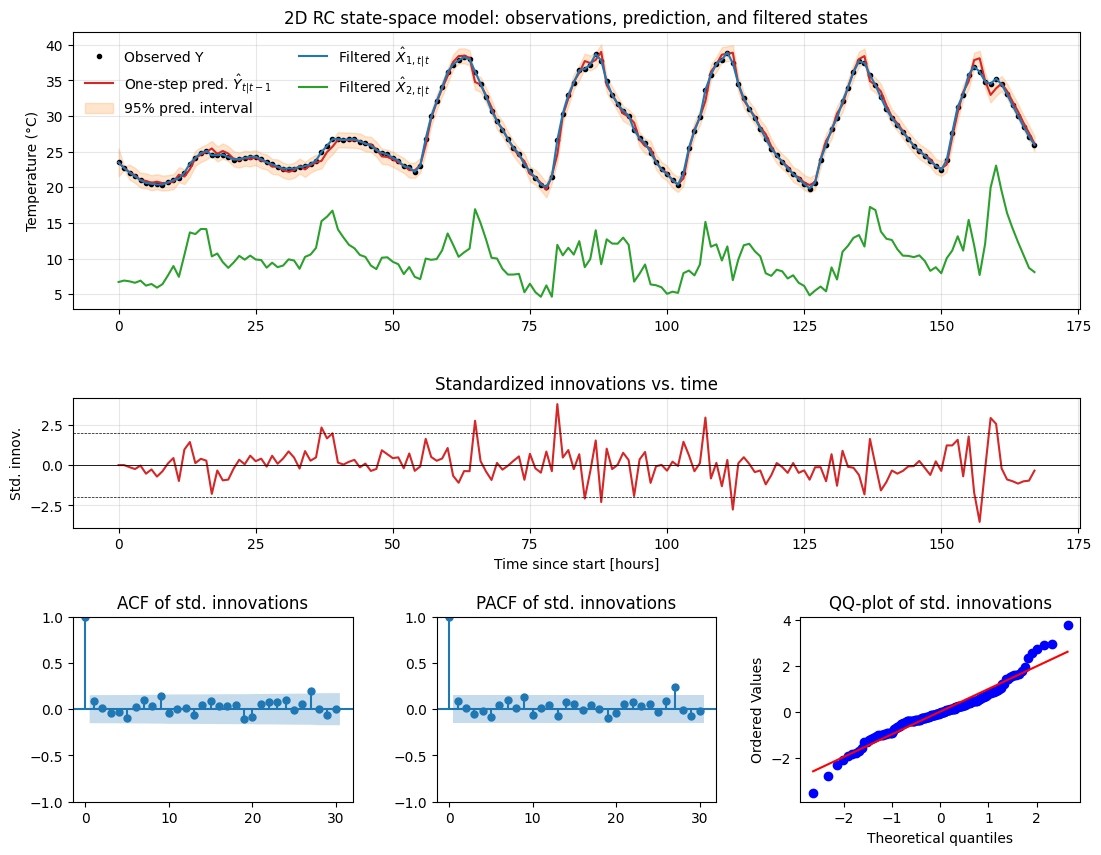

In [10]:
# ============================================================
# 8-9. FINAL FILTER + NUMERICAL DIAGNOSTICS + COMBINED FIGURE
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import matplotlib.gridspec as gridspec

# ---- Run final Kalman filter at the MLE --------------------

kf = kalman_filter(theta_hat, y, U, dt=dt)

x_pred = kf["x_pred"]          # predicted latent states, shape (n, 2)
x_filt = kf["x_filt"]          # filtered latent states, shape (n, 2)
y_pred = kf["y_pred"]          # one-step prediction of observed Y
innov = kf["innovation"]       # one-step prediction errors
S = kf["innovation_var"]       # innovation variances

sd_pred = np.sqrt(S)

# Standardized innovations
innov_std = innov / sd_pred

# Keep only valid values, useful if there are missing observations
valid = np.isfinite(innov_std)

innov_valid = innov[valid]
innov_std_valid = innov_std[valid]
S_valid = S[valid]
time = np.arange(len(df))          # hours since start
time_valid = time[valid]

# ---- Information criteria ----------------------------------

n_obs = np.sum(valid)
k = len(theta_hat)
logL = kf["loglik"]

AIC = 2 * k - 2 * logL
BIC = k * np.log(n_obs) - 2 * logL

# ---- Ljung-Box test -----------------------------------------

lb = acorr_ljungbox(innov_std_valid, lags=[10, 20], return_df=True)

# ---- Print numerical diagnostics ----------------------------

print("\nNumerical diagnostics")
print("---------------------")
print(f"n observations          = {n_obs}")
print(f"# parameters (k)        = {k}")
print(f"log-likelihood          = {logL:.4f}")
print(f"AIC                     = {AIC:.4f}")
print(f"BIC                     = {BIC:.4f}")
print(f"RMSE one-step           = {np.sqrt(np.mean(innov_valid**2)):.4f} °C")
print(f"Innovation mean / std   = {innov_valid.mean(): .4f} / {innov_valid.std(ddof=1):.4f}")
print(f"Std-innov mean / std    = {innov_std_valid.mean(): .4f} / {innov_std_valid.std(ddof=1):.4f}   (expect 0 / 1)")

print("\nLjung-Box test on standardized innovations:")
print(lb.to_string())

# ---- Single combined figure --------------------------------

max_lags = min(30, len(innov_std_valid) // 3)

fig = plt.figure(figsize=(13, 10))
gs = gridspec.GridSpec(
    3, 3,
    height_ratios=[3, 1.4, 2],
    hspace=0.45,
    wspace=0.30
)

# ============================================================
# (a) Observed Y + one-step prediction + latent states
# ============================================================

ax1 = fig.add_subplot(gs[0, :])

ax1.plot(time, y, "k.", label="Observed Y")

ax1.plot(
    time, y_pred,
    color="tab:red",
    label=r"One-step pred. $\hat Y_{t|t-1}$"
)

ax1.fill_between(
    time,
    y_pred - 1.96 * sd_pred,
    y_pred + 1.96 * sd_pred,
    color="tab:orange",
    alpha=0.20,
    label="95% pred. interval"
)

ax1.plot(
    time, x_filt[:, 0],
    color="tab:blue",
    label=r"Filtered $\hat X_{1,t|t}$"
)

ax1.plot(
    time, x_filt[:, 1],
    color="tab:green",
    label=r"Filtered $\hat X_{2,t|t}$"
)

ax1.set_ylabel("Temperature (°C)")
ax1.set_title("2D RC state-space model: observations, prediction, and filtered states")
ax1.legend(ncol=2, frameon=False)
ax1.grid(alpha=0.3)

# ============================================================
# (b) Standardized innovations over time
# ============================================================

ax2 = fig.add_subplot(gs[1, :], sharex=ax1)

ax2.plot(
    time_valid,
    innov_std_valid,
    color="tab:red"
)

ax2.axhline(0, color="k", lw=0.6)
ax2.axhline(1.96, color="k", lw=0.5, ls="--")
ax2.axhline(-1.96, color="k", lw=0.5, ls="--")

ax2.set_xlabel("Time since start [hours]")
ax2.set_ylabel("Std. innov.")
ax2.set_title("Standardized innovations vs. time")
ax2.grid(alpha=0.3)

# ============================================================
# (c) ACF, PACF, QQ plot
# ============================================================

ax3 = fig.add_subplot(gs[2, 0])
plot_acf(innov_std_valid, lags=max_lags, ax=ax3)
ax3.set_title("ACF of std. innovations")

ax4 = fig.add_subplot(gs[2, 1])
plot_pacf(innov_std_valid, lags=max_lags, ax=ax4, method="ywm")
ax4.set_title("PACF of std. innovations")

ax5 = fig.add_subplot(gs[2, 2])
stats.probplot(innov_std_valid, dist="norm", plot=ax5)
ax5.set_title("QQ-plot of std. innovations")

plt.show()

# 2.4

C:\Users\leahi\AppData\Local\Temp\ipykernel_33760\3207853312.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


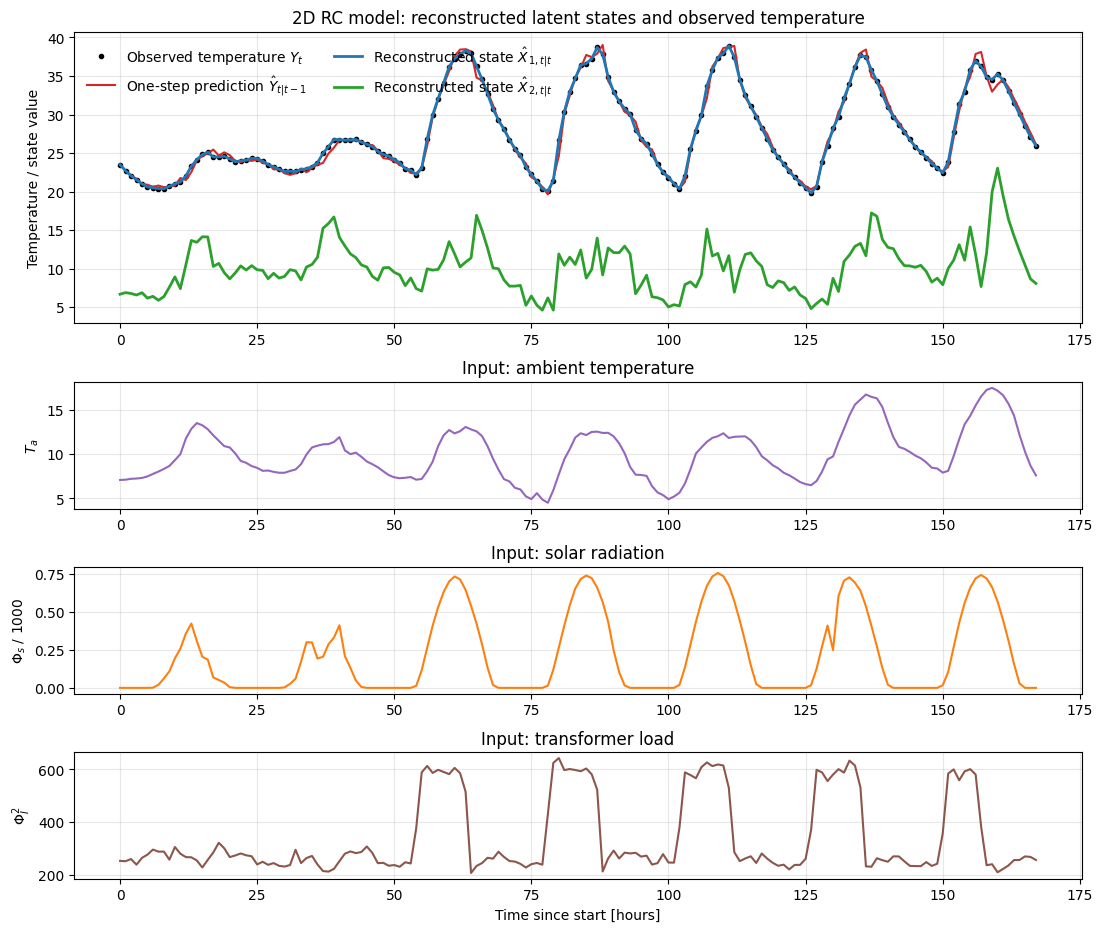

In [9]:
# ============================================================
# 2.4 INTERPRET THE TWO RECONSTRUCTED STATES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# ------------------------------------------------------------
# 1. Run Kalman filter at the estimated parameters
# ------------------------------------------------------------

kf = kalman_filter(theta_hat, y, U, dt=dt)

x_filt = kf["x_filt"]      # reconstructed / filtered states
x_pred = kf["x_pred"]      # predicted states
y_pred = kf["y_pred"]      # one-step predictions


# ------------------------------------------------------------
# 2. Input labels
# ------------------------------------------------------------

# This keeps labels consistent with whether you used I or I^2 in the model.
load_label = r"$\Phi_I^2$" if globals().get("USE_I_SQUARED", False) else r"$\Phi_I$"

input_names = [
    r"$T_a$",
    r"$\Phi_s$ / 1000",
    load_label,
]

state_names = [
    r"$\hat X_{1,t|t}$",
    r"$\hat X_{2,t|t}$",
]


# ------------------------------------------------------------
# 3. Plot reconstructed states and inputs in one figure
# ------------------------------------------------------------

# ------------------------------------------------------------
# 3. Plot reconstructed states and inputs in one figure
# ------------------------------------------------------------

fig = plt.figure(figsize=(13, 11))

gs = gridspec.GridSpec(
    4, 1,
    height_ratios=[3.0, 1.3, 1.3, 1.3],
    hspace=0.35
)

# Use hours since start instead of df["time"].
# The original "time" column is likely 0, 1, 2, ..., and converting it
# with pd.to_datetime makes matplotlib think it starts in year 1970.

time = np.arange(len(df))
# ------------------------------------------------------------
# Panel 1: observed temperature + reconstructed states
# ------------------------------------------------------------

ax1 = fig.add_subplot(gs[0, 0])

ax1.plot(time, y, "k.", label="Observed temperature $Y_t$")
ax1.plot(time, y_pred, color="tab:red", label=r"One-step prediction $\hat Y_{t|t-1}$")

ax1.plot(
    time,
    x_filt[:, 0],
    color="tab:blue",
    linewidth=2,
    label=r"Reconstructed state $\hat X_{1,t|t}$"
)

ax1.plot(
    time,
    x_filt[:, 1],
    color="tab:green",
    linewidth=2,
    label=r"Reconstructed state $\hat X_{2,t|t}$"
)

ax1.set_ylabel("Temperature / state value")
ax1.set_title("2D RC model: reconstructed latent states and observed temperature")
ax1.legend(ncol=2, frameon=False)
ax1.grid(alpha=0.3)


# ------------------------------------------------------------
# Panel 2: ambient temperature
# ------------------------------------------------------------

ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)

ax2.plot(time, U[:, 0], color="tab:purple")
ax2.set_ylabel(input_names[0])
ax2.set_title("Input: ambient temperature")
ax2.grid(alpha=0.3)


# ------------------------------------------------------------
# Panel 3: solar radiation
# ------------------------------------------------------------

ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)

ax3.plot(time, U[:, 1], color="tab:orange")
ax3.set_ylabel(input_names[1])
ax3.set_title("Input: solar radiation")
ax3.grid(alpha=0.3)


# ------------------------------------------------------------
# Panel 4: transformer load
# ------------------------------------------------------------

ax4 = fig.add_subplot(gs[3, 0], sharex=ax1)

ax4.plot(time, U[:, 2], color="tab:brown")
ax4.set_ylabel(input_names[2])
ax4.set_title("Input: transformer load")
ax4.set_xlabel("Time since start [hours]")
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# 4. ANALYZE ESTIMATED A AND B MATRICES
# ============================================================

A_c_hat, B_c_hat = continuous_matrices(theta_hat)
A_d_hat, B_d_hat, C_hat, Q_hat, R_hat = build_discrete_model(theta_hat, dt=dt)


# ------------------------------------------------------------
# Pretty matrix tables
# ------------------------------------------------------------

A_c_table = pd.DataFrame(
    A_c_hat,
    index=[r"dX1/dt", r"dX2/dt"],
    columns=[r"X1", r"X2"]
)

B_c_table = pd.DataFrame(
    B_c_hat,
    index=[r"dX1/dt", r"dX2/dt"],
    columns=input_names
)

A_d_table = pd.DataFrame(
    A_d_hat,
    index=[r"X1_{t+1}", r"X2_{t+1}"],
    columns=[r"X1_t", r"X2_t"]
)

B_d_table = pd.DataFrame(
    B_d_hat,
    index=[r"X1_{t+1}", r"X2_{t+1}"],
    columns=input_names
)

print("\nContinuous-time A_c matrix")
print("--------------------------")
print(A_c_table)

print("\nContinuous-time B_c matrix")
print("--------------------------")
print(B_c_table)

print("\nDiscrete-time A matrix")
print("----------------------")
print(A_d_table)

print("\nDiscrete-time B matrix")
print("----------------------")
print(B_d_table)

print("\nObservation matrix C")
print("--------------------")
print(C_hat)

print("\nProcess-noise covariance Q")
print("--------------------------")
print(Q_hat)

print("\nObservation-noise covariance R")
print("------------------------------")
print(R_hat)


Continuous-time A_c matrix
--------------------------
             X1       X2
dX1/dt -0.23057  0.23057
dX2/dt  0.00001 -0.78425

Continuous-time B_c matrix
--------------------------
          $T_a$  $\Phi_s$ / 1000  $\Phi_I^2$
dX1/dt  0.00000          0.00000     0.01177
dX2/dt  0.78424          0.00001     0.00000

Discrete-time A matrix
----------------------
              X1_t      X2_t
X1_{t+1}  0.794082  0.140595
X2_{t+1}  0.000006  0.456462

Discrete-time B matrix
----------------------
             $T_a$  $\Phi_s$ / 1000    $\Phi_I^2$
X1_{t+1}  0.065323     8.329468e-07  1.051122e-02
X2_{t+1}  0.543532     6.930675e-06  4.251807e-08

Observation matrix C
--------------------
[[1. 0.]]

Process-noise covariance Q
--------------------------
[[1.00000000e-08 0.00000000e+00]
 [0.00000000e+00 1.46137421e+01]]

Observation-noise covariance R
------------------------------
[[1.e-08]]


In [6]:
# ============================================================
# 5. EIGENVALUES AND THERMAL TIME SCALES
# ============================================================

def discrete_time_constant(lambda_d, dt=1.0):
    """
    Convert a stable discrete-time eigenvalue into an approximate time constant.

    If lambda = exp(-dt / tau), then:
        tau = -dt / log(abs(lambda))
    """

    lam_abs = np.abs(lambda_d)

    if lam_abs <= 0 or lam_abs >= 1:
        return np.nan

    return -dt / np.log(lam_abs)


eigvals = np.linalg.eigvals(A_d_hat)
taus = np.array([discrete_time_constant(lam, dt=dt) for lam in eigvals])

timescale_table = pd.DataFrame({
    "Eigenvalue of A": eigvals,
    "Approx. time constant [h]": taus,
})

print("\nEigenvalue-based time scales")
print("----------------------------")
print(timescale_table)


Eigenvalue-based time scales
----------------------------
   Eigenvalue of A  Approx. time constant [h]
0         0.794084                   4.337158
1         0.456460                   1.275096


# 2.1

Load the provided dataset.

• Plot all four variables (Yt, Ta,t, Φs,t, ΦI,t) together in a single figure, using different colors
or panels.

• Use appropriate labels and time axes for clarity.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

fp = "C:\\Users\\leahi\\Documents\\DTU\\Time Series Analysis\\assignments\\Assignment4\\transformer_data.csv"
df = pd.read_csv(fp)

In [ ]:
# Use the numeric hour `time` as x-axis
x = df["time"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x, df["Y"], color="tab:red", label="Y: transformer temperature")
ax.plot(x, df["Ta"], color="tab:blue", label="Ta: outdoor air temperature")
ax.plot(x, df["S"], color="tab:orange", label="S: solar radiation")
ax.plot(x, df["I"], color="tab:green", label="I: transformer load")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Value")
ax.set_title("Transformer station data over time")
ax.grid(alpha=0.3)
ax.legend(ncol=2, frameon=False)

# Optional: nicer x-ticks every 24 hours
try:
    step = 24
    xt = list(range(int(x.min()), int(x.max()) + 1, step))
    ax.set_xticks(xt)
except Exception:
    pass

plt.tight_layout()
plt.show()

In [ ]:


# Use the numeric hour `time` as x-axis
x = df["time"]

# Plot in 4 stacked panels (shared x-axis)
cols = ["Y", "Ta", "S", "I"]
colors = ["tab:red", "tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 8))
for ax, col, c in zip(axes, cols, colors):
    ax.plot(x, df[col], color=c)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (hours)")
fig.suptitle("Transformer data: Y (temp), Ta (air), S (solar), I (load)", y=1.02)
plt.tight_layout()

# Optional: nicer x-ticks every 24 hours
try:
    step = 24
    xt = list(range(int(x.min()), int(x.max()) + 1, step))
    axes[-1].set_xticks(xt)
except Exception:
    pass

plt.show()

# 2.2

Estimate a 1-dimensional state-space model: 
We now aim to fit a simple 1-dimensional state-space model of the form:
Xt+1 = AXt + But + Ge1,t,
Yt = CXt + e2,t,
where ut = [Ta,t,Φs,t,ΦI,t]T is the input vector. (Note: Here we use G to scale the system noise.)
You will use the provided R functions in functions exercise2.R, but you must fill in missing
parts.


Implement:
•Complete the functions kf logLik dt and estimate dt.
•Map the parameter vector to the appropriate matrices A, B, G, C, Σx, Σy.
•Estimate the model parameters by maximizing the likelihood (use optim).
•Adjust the initial guesses and parameter bounds if necessary to achieve a good fit

## 2.2 — Physical 1-D resistor–capacitor (RC) state-space model

Instead of an abstract 1-D model where `A`, `B` are free numbers, we use a **lumped RC thermal model** whose parameters have physical meaning. The transformer station is treated as a single thermal mass with heat capacity $C_x$ that exchanges heat with the ambient air through a thermal resistance $R_{xa}$, and is heated by solar radiation $\Phi_{s,t}$ and electrical load $\Phi_{I,t}$:

$$
C_x\,\dot X(t)=\frac{1}{R_{xa}}\bigl(T_a(t)-X(t)\bigr)+a\,\Phi_s(t)+b\,\Phi_I(t)
$$

Dividing by $C_x$:

$$
\dot X(t)=-\frac{1}{\tau}\,X(t)+\frac{1}{\tau}\,T_a(t)+A_s\,\Phi_s(t)+A_I\,\Phi_I(t)
$$

with the **identifiable** physical parameters

$$
\tau = C_x R_{xa}\ [\text{h}],\quad
A_s = \tfrac{a}{C_x}\ [\text{°C}\cdot\text{m}^2/\text{W}\cdot\text{h}],\quad
A_I = \tfrac{b}{C_x}\ [\text{°C}/\text{kA}\cdot\text{h}].
$$

(Note: from observations of $Y$ alone, $C_x$ and $R_{xa}$ can only be identified through their product $\tau$ — and $a,b$ only through $A_s = a/C_x$, $A_I = b/C_x$ — so we estimate $\tau, A_s, A_I$ directly.)

Continuous-time state-space form with $u=[T_a,\Phi_s,\Phi_I]^T$:

$$
A_c=-\tfrac{1}{\tau},\qquad B_c=\bigl[\tfrac{1}{\tau},\ A_s,\ A_I\bigr]
$$

We discretize with sampling step $\Delta t = 1$ hour using the block matrix exponential (§32–33 of the notes):

$$
\exp\!\left(\begin{bmatrix}A_c & B_c\\ 0 & 0\end{bmatrix}\Delta t\right)
=\begin{bmatrix}A_d & B_d\\ 0 & I\end{bmatrix}
$$

giving the discrete-time model
$$
X_{t+1}=A_d X_t + B_d u_t + G\,e_{1,t},\qquad Y_t = X_t + e_{2,t},
$$
with $G=1$, $e_{1,t}\sim\mathcal N(0,\sigma_1^2)$, $e_{2,t}\sim\mathcal N(0,\sigma_2^2)$.

**Estimated parameters** (positive — optimized in log-space): $\tau,\,A_s,\,A_I,\,\sigma_1,\,\sigma_2$.
The log-likelihood is built from the Kalman one-step innovations (§13, §20 of the notes).


In [4]:
import numpy as np
from scipy.linalg import expm
from scipy.optimize import minimize

# ---- Data: state-space ingredients ---------------------------------------
# Inputs u_t = [Ta, S, I]^T  (rows = time)
U = df[["Ta", "S", "I"]].to_numpy()
Y = df["Y"].to_numpy()
N = len(Y)
dt = 1.0  # sampling interval = 1 hour

# ---- Build discrete-time RC matrices from identifiable physical params ---
def build_discrete(tau, As, AI, dt=1.0):
    """Discretize the continuous-time 1-state RC model with the block matrix
    exponential.  Parameters:
        tau : thermal time constant (h),  Ac = -1/tau
        As  : solar gain  (Bc coeff. on S)
        AI  : load  gain  (Bc coeff. on I)
    Returns scalar A_d and 1x3 row B_d."""
    Ac = np.array([[-1.0 / tau]])
    Bc = np.array([[1.0 / tau, As, AI]])
    # Block matrix for exact joint discretization of A and B
    M = np.zeros((4, 4))
    M[0:1, 0:1] = Ac
    M[0:1, 1:4] = Bc
    Md = expm(M * dt)
    Ad = Md[0:1, 0:1]
    Bd = Md[0:1, 1:4]
    return Ad, Bd

# ---- Kalman filter + log-likelihood for the RC model ---------------------
# Convention: the input U[t-1] (held constant over [t-1, t]) drives the
# transition X_{t-1} -> X_t, consistent with X_{t+1} = A X_t + B u_t + ...
# NOTE on noise: sigma1 is the *discrete-time* process-noise std (we set
# Q_d = sigma1^2 directly, we are NOT integrating a continuous-time noise
# spectral density through the matrix exponential). sigma2 is the
# observation-noise std (sensor noise on Y).
def kf_logLik_rc(par, Y, U, dt=1.0, X0=None, P0=1e2, return_filter=False):
    """par = [log tau, log As, log AI, log sigma1, log sigma2].
    Physical parameters are forced positive via the log-parameterization."""
    tau, As, AI, sigma1, sigma2 = np.exp(par)

    Ad, Bd = build_discrete(tau, As, AI, dt)
    C = np.array([[1.0]])
    Q = np.array([[sigma1 ** 2]])      # discrete-time process-noise variance
    R = np.array([[sigma2 ** 2]])      # observation-noise variance

    n = 1
    # Initialization: use first observation as a reasonable guess (§4, case 3)
    x_est = np.array([[Y[0] if X0 is None else X0]])
    P_est = np.array([[P0]])

    Tn = len(Y)
    logLik = 0.0

    if return_filter:
        x_pred_hist = np.zeros(Tn)
        x_filt_hist = np.zeros(Tn)
        P_pred_hist = np.zeros(Tn)
        P_filt_hist = np.zeros(Tn)
        innov_hist  = np.zeros(Tn)
        S_hist      = np.zeros(Tn)

    for t in range(Tn):
        # --- Prediction step ---------------------------------------------
        # X_t = A_d * X_{t-1} + B_d * U[t-1]  (U[t-1] drives X_{t-1} -> X_t)
        # At t = 0 we have no prior transition; use the initial prior.
        if t == 0:
            x_pred = x_est
            P_pred = P_est
        else:
            u_prev = U[t - 1].reshape(3, 1)
            x_pred = Ad @ x_est + Bd @ u_prev
            P_pred = Ad @ P_est @ Ad.T + Q

        # --- Innovation step ----------------------------------------------
        y_pred = C @ x_pred
        S_t    = C @ P_pred @ C.T + R
        innov  = Y[t] - y_pred[0, 0]

        # --- Log-likelihood contribution (Gaussian) -----------------------
        logLik += -0.5 * (np.log(2 * np.pi * S_t[0, 0]) + innov ** 2 / S_t[0, 0])

        # --- Update step --------------------------------------------------
        K_t   = P_pred @ C.T / S_t[0, 0]
        x_est = x_pred + K_t * innov
        P_est = (np.eye(n) - K_t @ C) @ P_pred

        if return_filter:
            x_pred_hist[t] = x_pred[0, 0]
            x_filt_hist[t] = x_est[0, 0]
            P_pred_hist[t] = P_pred[0, 0]
            P_filt_hist[t] = P_est[0, 0]
            innov_hist[t]  = innov
            S_hist[t]      = S_t[0, 0]

    if return_filter:
        return {
            "logLik": float(logLik),
            "x_pred": x_pred_hist, "P_pred": P_pred_hist,
            "x_filt": x_filt_hist, "P_filt": P_filt_hist,
            "innovation": innov_hist, "S": S_hist,
            "params": dict(tau=tau, As=As, AI=AI,
                           sigma1=sigma1, sigma2=sigma2),
        }
    return float(logLik)

def neg_logLik_rc(par, Y, U, dt=1.0):
    return -kf_logLik_rc(par, Y, U, dt)


In [5]:
# ---- Estimate the RC parameters by maximum likelihood --------------------
# Physical-ish initial guesses:
#   tau      ~ a few hours  (thermal inertia of the transformer station)
#   As, AI   small positive gains
#   sigma1   process-noise std (modelling error in °C/h)
#   sigma2   measurement-noise std (sensor noise in °C, > 0.05 realistic)
start_phys = dict(tau=3.0, As=1e-3, AI=0.5, sigma1=0.5, sigma2=0.2)
par_names = ["tau", "As", "AI", "sigma1", "sigma2"]
par0 = np.log([start_phys[k] for k in par_names])

# Bounds in log-space (sigma2 floored at 0.05 °C — realistic sensor noise)
log_lb = np.log([0.1,  1e-6, 1e-4, 1e-3, 0.05])
log_ub = np.log([100., 1e1,  1e2,  10.,  10.  ])

# Try several random restarts to avoid the local-optimum trap
rng = np.random.default_rng(0)
best = None
for k in range(8):
    if k == 0:
        p_init = par0
    else:
        p_init = par0 + rng.normal(scale=1.0, size=par0.size)
        p_init = np.clip(p_init, log_lb, log_ub)
    r = minimize(
        neg_logLik_rc, p_init, args=(Y, U, dt),
        method="L-BFGS-B",
        bounds=list(zip(log_lb, log_ub)),
        options=dict(maxiter=500, ftol=1e-10, gtol=1e-8),
    )
    if (best is None) or (r.fun < best.fun):
        best = r

res = best
par_hat = res.x
phys_hat = dict(zip(par_names, np.exp(par_hat)))

print(f"Optimization success: {res.success} | neg-logLik = {res.fun:.4f}")
print("Estimated identifiable physical parameters:")
for k in par_names:
    print(f"  {k:7s} = {phys_hat[k]: .6g}")

# Show which parameters are sitting on a bound (warning signal)
at_lb = np.isclose(par_hat, log_lb, atol=1e-4)
at_ub = np.isclose(par_hat, log_ub, atol=1e-4)
if at_lb.any() or at_ub.any():
    print("\nWARNING: parameters at a bound:")
    for i, name in enumerate(par_names):
        if at_lb[i]: print(f"  {name} at LOWER bound ({np.exp(log_lb[i]):.4g})")
        if at_ub[i]: print(f"  {name} at UPPER bound ({np.exp(log_ub[i]):.4g})")

# Resulting discrete-time matrices and 1-step state-transition coefficient
Ad_hat, Bd_hat = build_discrete(phys_hat["tau"], phys_hat["As"], phys_hat["AI"], dt)
print(f"\nDiscrete-time A_d  = {Ad_hat[0,0]:.4f}   (≈ exp(-Δt/τ))")
print(f"Discrete-time B_d  = [{Bd_hat[0,0]:.4g}, {Bd_hat[0,1]:.4g}, {Bd_hat[0,2]:.4g}]"
      "   (coeffs on Ta, S, I)")


Optimization success: True | neg-logLik = 187.4186
Estimated identifiable physical parameters:
  tau     =  2.55236
  As      =  0.00198753
  AI      =  0.360472
  sigma1  =  0.728141
  sigma2  =  0.05

  sigma2 at LOWER bound (0.05)

Discrete-time A_d  = 0.6758   (≈ exp(-Δt/τ))
Discrete-time B_d  = [0.3242, 0.001644, 0.2982]   (coeffs on Ta, S, I)


In [6]:
# ---- Explicit parameter-vector -> matrices map ---------------------------
# θ = [log τ, log A_s, log A_I, log σ_1, log σ_2]   (estimated in log-space)
# maps to the discrete-time state-space matrices:
#   X_{t+1} = A X_t + B u_t + G e_{1,t},   e_{1,t} ~ N(0, Σ_x)
#   Y_t     = C X_t + e_{2,t},             e_{2,t} ~ N(0, Σ_y)

def theta_to_matrices(par, dt=1.0):
    tau, As, AI, sigma1, sigma2 = np.exp(par)
    Ad, Bd = build_discrete(tau, As, AI, dt)       # 1x1, 1x3
    A      = Ad                                     # state-transition matrix
    B      = Bd                                     # input matrix
    G      = np.array([[1.0]])                      # process-noise loading
    C      = np.array([[1.0]])                      # observation matrix
    Sigma_x = np.array([[sigma1 ** 2]])             # process-noise covariance
    Sigma_y = np.array([[sigma2 ** 2]])             # observation-noise covariance
    return A, B, G, C, Sigma_x, Sigma_y

A_hat, B_hat, G_hat, C_hat, Sx_hat, Sy_hat = theta_to_matrices(par_hat, dt)

print("State-space matrices at the MLE:")
print(f"  A  = {A_hat}")
print(f"  B  = {B_hat}        (columns: Ta, S, I)")
print(f"  G  = {G_hat}")
print(f"  C  = {C_hat}")
print(f"  Σx = {Sx_hat}        (= σ₁² = {Sx_hat[0,0]:.4g})")
print(f"  Σy = {Sy_hat}        (= σ₂² = {Sy_hat[0,0]:.4g})")


State-space matrices at the MLE:
  A  = [[0.67584273]]
  B  = [[0.32415727 0.00164441 0.29824149]]        (columns: Ta, S, I)
  G  = [[1.]]
  C  = [[1.]]
  Σx = [[0.53018862]]        (= σ₁² = 0.5302)
  Σy = [[0.0025]]        (= σ₂² = 0.0025)


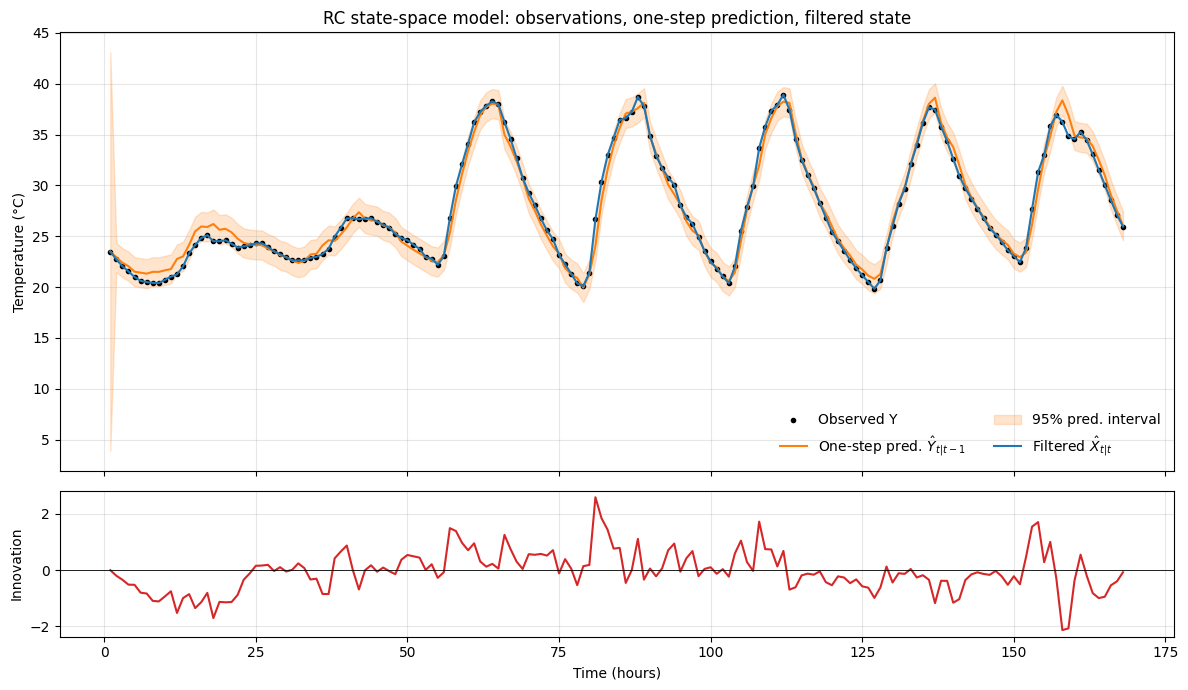

Innovation mean  = -0.0528
Innovation std   =  0.7272
RMSE one-step    =  0.7269 °C


In [8]:
# ---- Run the Kalman filter at the MLE and visualise the fit --------------
kf = kf_logLik_rc(par_hat, Y, U, dt, return_filter=True)

x_pred = kf["x_pred"]
x_filt = kf["x_filt"]
sd_pred = np.sqrt(kf["S"])  # std of one-step-ahead prediction of Y

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

ax = axes[0]
ax.plot(df["time"], Y, "k.", label="Observed Y")
ax.plot(df["time"], x_pred, color="tab:orange",
        label=r"One-step pred. $\hat Y_{t|t-1}$")
ax.fill_between(df["time"], x_pred - 1.96 * sd_pred, x_pred + 1.96 * sd_pred,
                color="tab:orange", alpha=0.2, label="95% pred. interval")
ax.plot(df["time"], x_filt, color="tab:blue",
        label=r"Filtered $\hat X_{t|t}$")
ax.set_ylabel("Temperature (°C)")
ax.set_title("RC state-space model: observations, one-step prediction, filtered state")
ax.legend(ncol=2, frameon=False)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df["time"], kf["innovation"], color="tab:red")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Innovation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Quick residual diagnostics
innov = kf["innovation"]
print(f"Innovation mean  = {innov.mean(): .4f}")
print(f"Innovation std   = {innov.std(ddof=1): .4f}")
print(f"RMSE one-step    = {np.sqrt((innov**2).mean()): .4f} °C")


n observations       = 168
# parameters (k)     = 5
log-likelihood       = -187.0635
AIC                  = 384.1270
BIC                  = 399.7468
Innovation mean      = -0.0527
Innovation std       =  0.7256
Std-innov mean       = -0.0724    (expect ≈ 0)
Std-innov std        =  0.9974    (expect ≈ 1)

Ljung-Box test on standardised innovations:
       lb_stat     lb_pvalue
10  215.029428  1.171980e-40
20  261.657479  5.047314e-44


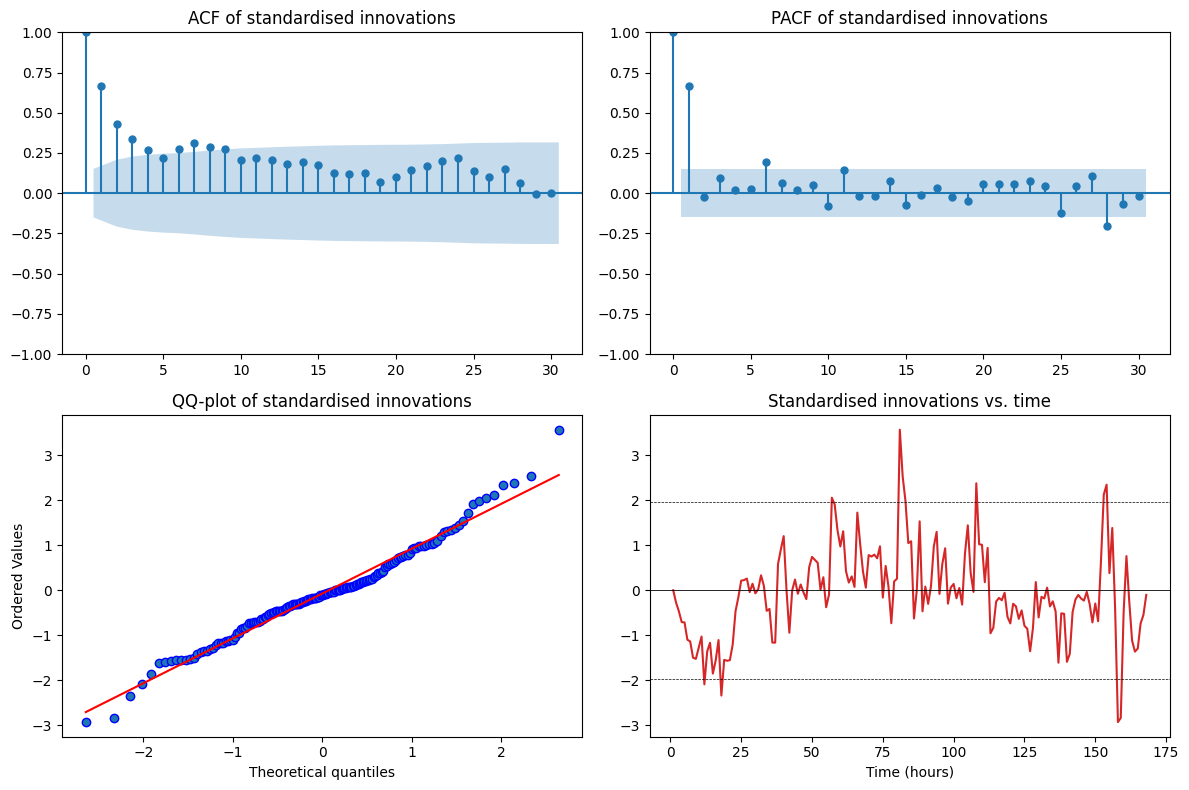

In [11]:
# ---- Residual diagnostics: ACF, PACF, QQ-plot, AIC, BIC ------------------
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

innov = kf["innovation"]
S     = kf["S"]
n_obs = len(innov)
k     = len(par_hat)                  # number of estimated parameters (= 5)

# Standardised innovations: should be ~ N(0,1) and white if the model is OK
innov_std = innov / np.sqrt(S)

# Information criteria from the maximised log-likelihood
logL = -res.fun
AIC  = 2 * k - 2 * logL
BIC  = k * np.log(n_obs) - 2 * logL

print(f"n observations       = {n_obs}")
print(f"# parameters (k)     = {k}")
print(f"log-likelihood       = {logL:.4f}")
print(f"AIC                  = {AIC:.4f}")
print(f"BIC                  = {BIC:.4f}")
print(f"Innovation mean      = {innov.mean(): .4f}")
print(f"Innovation std       = {innov.std(ddof=1): .4f}")
print(f"Std-innov mean       = {innov_std.mean(): .4f}    (expect ≈ 0)")
print(f"Std-innov std        = {innov_std.std(ddof=1): .4f}    (expect ≈ 1)")

# Ljung-Box test on standardised innovations for residual autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(innov_std, lags=[10, 20], return_df=True)
print("\nLjung-Box test on standardised innovations:")
print(lb.to_string())

# --- Plots: ACF, PACF, QQ, residual time series ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(innov_std, lags=30, ax=axes[0, 0])
axes[0, 0].set_title("ACF of standardised innovations")

plot_pacf(innov_std, lags=30, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF of standardised innovations")

stats.probplot(innov_std, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-plot of standardised innovations")
axes[1, 0].get_lines()[0].set_markerfacecolor("tab:blue")

axes[1, 1].plot(df["time"], innov_std, color="tab:red")
axes[1, 1].axhline(0,  color="k", lw=0.6)
axes[1, 1].axhline( 1.96, color="k", lw=0.5, ls="--")
axes[1, 1].axhline(-1.96, color="k", lw=0.5, ls="--")
axes[1, 1].set_title("Standardised innovations vs. time")
axes[1, 1].set_xlabel("Time (hours)")

plt.tight_layout()
plt.show()


n observations       = 168
# parameters (k)     = 5
log-likelihood       = -187.4186
AIC                  = 384.8372
BIC                  = 400.4571
RMSE one-step        = 0.7269 °C
Innovation mean / std = -0.0528 / 0.7272
Std-innov mean / std = -0.0723 / 0.9952   (expect 0 / 1)

Ljung-Box test on standardised innovations:
       lb_stat     lb_pvalue
10  216.261607  6.474233e-41
20  263.156229  2.510476e-44


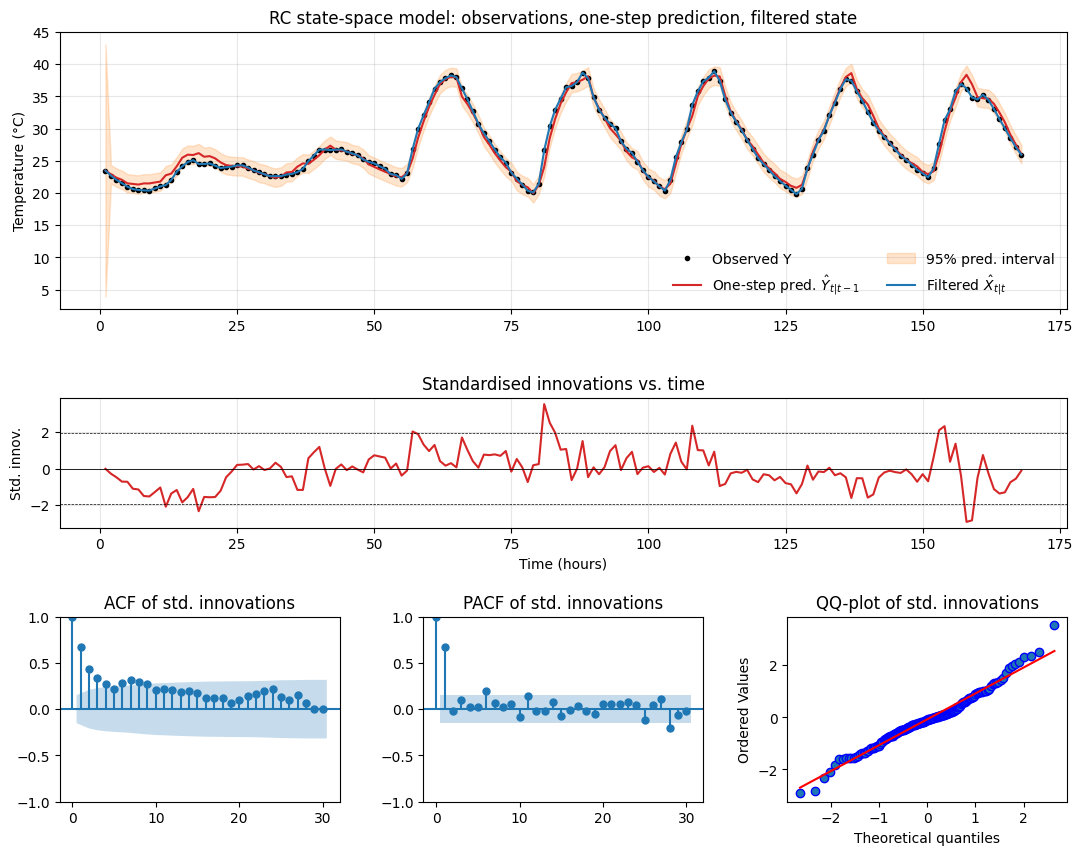

In [10]:
# ---- Run the Kalman filter at the MLE: fit + residual diagnostics --------
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import matplotlib.gridspec as gridspec

kf = kf_logLik_rc(par_hat, Y, U, dt, return_filter=True)

x_pred  = kf["x_pred"]
x_filt  = kf["x_filt"]
innov   = kf["innovation"]
S       = kf["S"]
sd_pred = np.sqrt(S)

# Standardised innovations (should be ~ N(0,1) and white if the model is OK)
innov_std = innov / sd_pred

# Information criteria
n_obs = len(innov)
k     = len(par_hat)
logL  = -res.fun
AIC   = 2 * k - 2 * logL
BIC   = k * np.log(n_obs) - 2 * logL

# Ljung-Box on standardised innovations
lb = acorr_ljungbox(innov_std, lags=[10, 20], return_df=True)

# --- Print numerical diagnostics ------------------------------------------
print(f"n observations       = {n_obs}")
print(f"# parameters (k)     = {k}")
print(f"log-likelihood       = {logL:.4f}")
print(f"AIC                  = {AIC:.4f}")
print(f"BIC                  = {BIC:.4f}")
print(f"RMSE one-step        = {np.sqrt((innov**2).mean()):.4f} °C")
print(f"Innovation mean / std = {innov.mean(): .4f} / {innov.std(ddof=1):.4f}")
print(f"Std-innov mean / std = {innov_std.mean(): .4f} / {innov_std.std(ddof=1):.4f}   (expect 0 / 1)")
print("\nLjung-Box test on standardised innovations:")
print(lb.to_string())

# --- Single combined figure -----------------------------------------------
fig = plt.figure(figsize=(13, 10))
gs  = gridspec.GridSpec(3, 3, height_ratios=[3, 1.4, 2], hspace=0.45, wspace=0.3)

# (a) Observed Y + one-step prediction + filtered state ---------------------
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df["time"], Y, "k.", label="Observed Y")
ax1.plot(df["time"], x_pred, color="tab:red",
         label=r"One-step pred. $\hat Y_{t|t-1}$")
ax1.fill_between(df["time"], x_pred - 1.96 * sd_pred, x_pred + 1.96 * sd_pred,
                 color="tab:orange", alpha=0.2, label="95% pred. interval")
ax1.plot(df["time"], x_filt, color="tab:blue",
         label=r"Filtered $\hat X_{t|t}$")
ax1.set_ylabel("Temperature (°C)")
ax1.set_title("RC state-space model: observations, one-step prediction, filtered state")
ax1.legend(ncol=2, frameon=False)
ax1.grid(alpha=0.3)

# (b) Standardised innovations vs. time ------------------------------------
ax2 = fig.add_subplot(gs[1, :], sharex=ax1)
ax2.plot(df["time"], innov_std, color="tab:red")
ax2.axhline(0,     color="k", lw=0.6)
ax2.axhline( 1.96, color="k", lw=0.5, ls="--")
ax2.axhline(-1.96, color="k", lw=0.5, ls="--")
ax2.set_xlabel("Time (hours)")
ax2.set_ylabel("Std. innov.")
ax2.set_title("Standardised innovations vs. time")
ax2.grid(alpha=0.3)

# (c) ACF, PACF, QQ-plot of standardised innovations -----------------------
ax3 = fig.add_subplot(gs[2, 0])
plot_acf(innov_std, lags=30, ax=ax3)
ax3.set_title("ACF of std. innovations")

ax4 = fig.add_subplot(gs[2, 1])
plot_pacf(innov_std, lags=30, ax=ax4, method="ywm")
ax4.set_title("PACF of std. innovations")

ax5 = fig.add_subplot(gs[2, 2])
stats.probplot(innov_std, dist="norm", plot=ax5)
ax5.set_title("QQ-plot of std. innovations")
ax5.get_lines()[0].set_markerfacecolor("tab:blue")

plt.show()